In [1]:
# Import + Load Data
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

data = pd.read_csv("customer churn.csv")

# Drop ID column
X = data.drop(["Churn", "customerID"], axis=1)
y = data["Churn"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          No       0.49      0.55      0.52       584
         Yes       0.50      0.44      0.47       592

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176



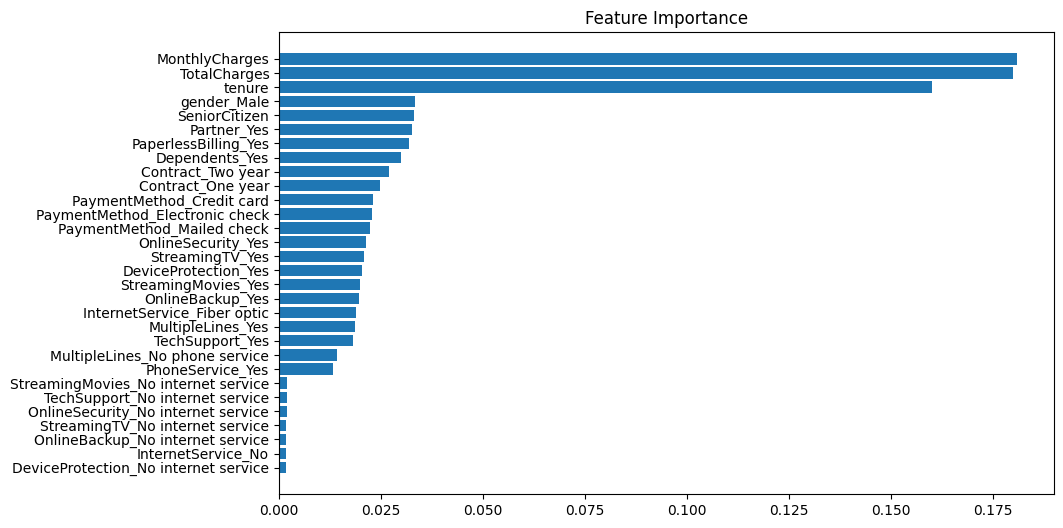

In [2]:
# Feature Importance
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

100%|===================| 2346/2352 [05:48<00:00]        

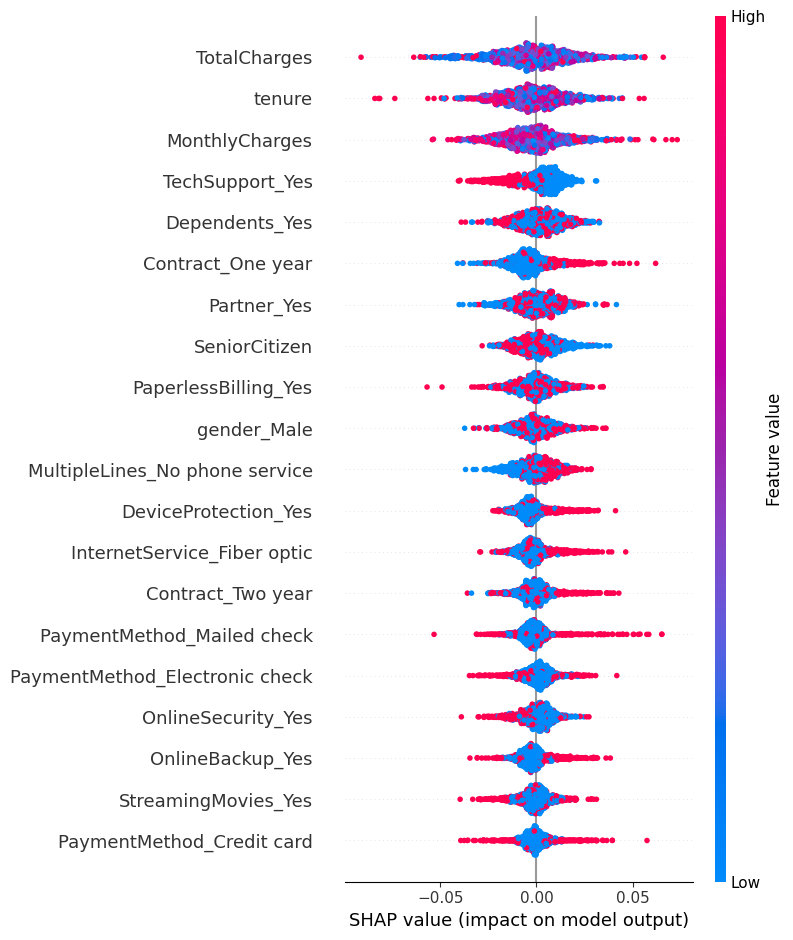

In [3]:
# SHAP Summary
import shap

X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

explainer = shap.Explainer(model, X_train_numeric)
shap_values = explainer(X_test_numeric)

shap.summary_plot(shap_values[:, :, 1], X_test_numeric)

In [4]:
# SHAP Force Plot
import shap
shap.initjs()

shap.force_plot(
    shap_values[0, :, 1]
)

In [5]:
pip install --upgrade ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# LIME
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML
import numpy as np

# Convert to numpy (important for LIME)
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

explainer = LimeTabularExplainer(
    X_train_np,
    feature_names=X.columns.tolist(),
    class_names=["No Churn","Churn"],
    mode="classification"
)

exp = explainer.explain_instance(
    X_test_np[0],   # ✅ use numpy version here
    model.predict_proba,
    num_features=10
)

# ✅ FORCE HTML DISPLAY (no internal LIME call)
html = exp.as_html()
display(HTML(html))

C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [8]:
# Bias (Gender Accuracy)
test_df = X_test.copy()
test_df["Actual"] = y_test
test_df["Predicted"] = pred

bias_gender = test_df.groupby("gender_Male").apply(
    lambda x: (x["Predicted"] == x["Actual"]).mean(),
    include_groups=False
)

print("Accuracy by Gender (0 = Female, 1 = Male):")
print(bias_gender)

Accuracy by Gender (0 = Female, 1 = Male):
gender_Male
False    0.478417
True     0.514516
dtype: float64


In [9]:
# Prediction Rate (Gender)
test_df.groupby("gender_Male")["Predicted"].apply(lambda x: (x == "Yes").mean())

gender_Male
False    0.449640
True     0.443548
Name: Predicted, dtype: float64

In [10]:
# False Positive Rate (FPR)
from sklearn.metrics import confusion_matrix

def fpr(group):
    tn, fp, fn, tp = confusion_matrix(
        group["Actual"], group["Predicted"], labels=["No", "Yes"]
    ).ravel()
    return fp/(fp+tn)

test_df.groupby("gender_Male").apply(fpr, include_groups=False)

gender_Male
False    0.471831
True     0.426667
dtype: float64

In [11]:
# Senior Citizen Bias
test_df.groupby("SeniorCitizen")["Predicted"].apply(lambda x: (x == "Yes").mean())

SeniorCitizen
0    0.423588
1    0.470383
Name: Predicted, dtype: float64

In [12]:
# SMOTE (Bias Mitigation)
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_res, y_res = sm.fit_resample(X_train, y_train)

In [13]:
# Model after SMOTE
print(classification_report(y_test, model.fit(X_res, y_res).predict(X_test)))

              precision    recall  f1-score   support

          No       0.49      0.54      0.52       584
         Yes       0.49      0.44      0.47       592

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176



100%|===================| 2350/2352 [07:04<00:00]        

Generating SHAP Summary Plot


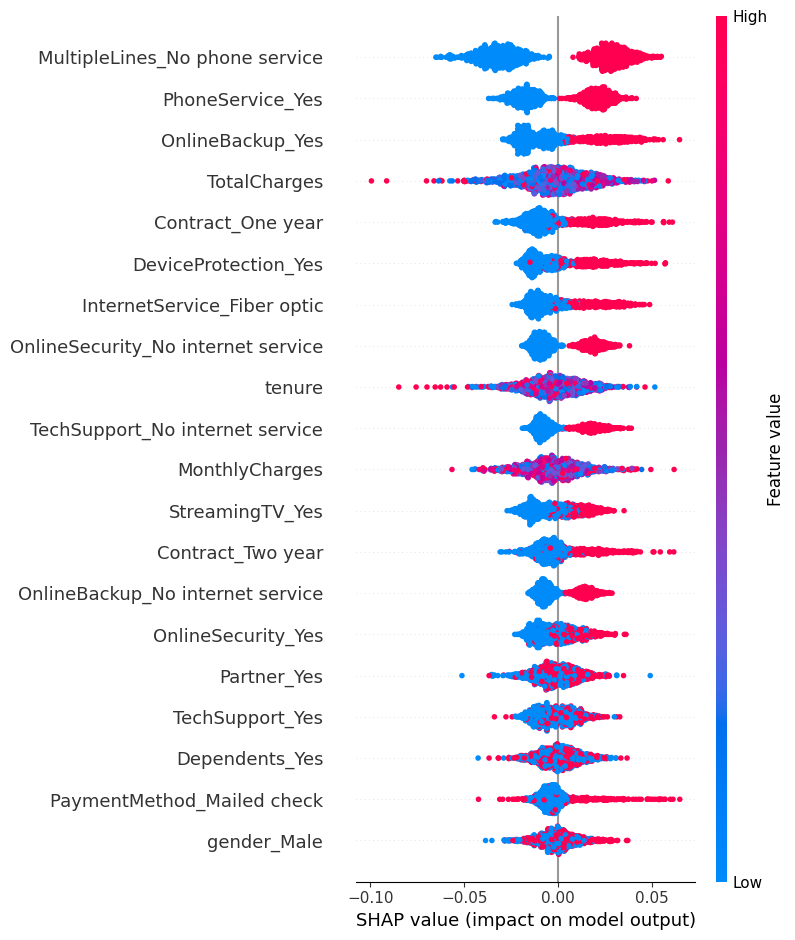

Generating SHAP Bar Plot


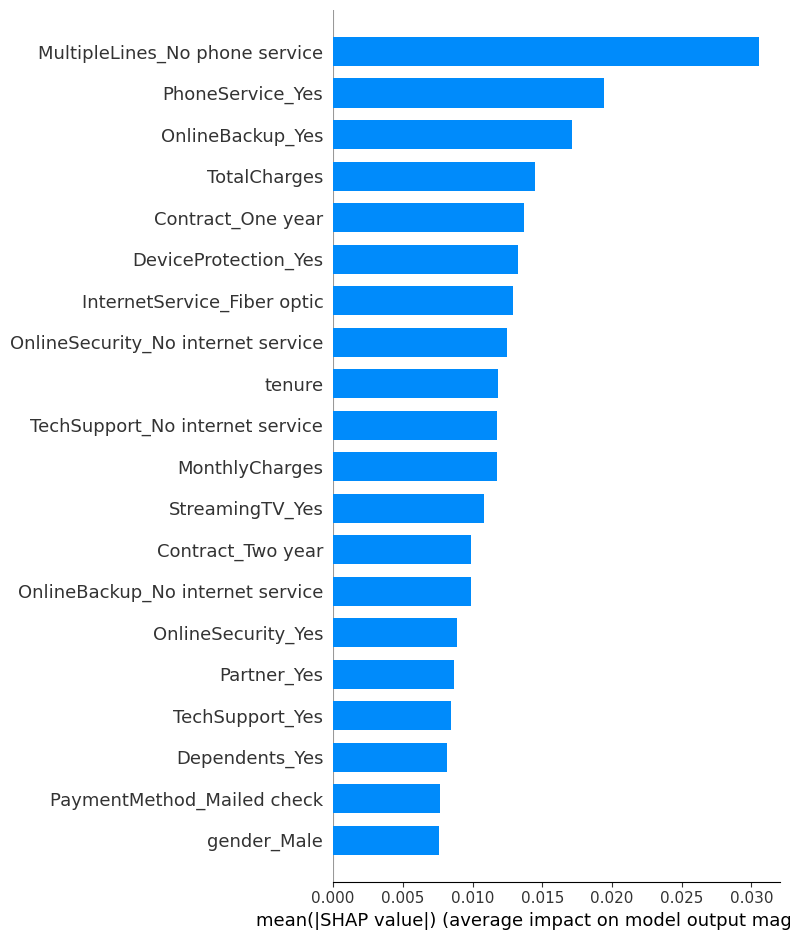


BIAS BEFORE MITIGATION

Feature: gender_Male
   group  accuracy       FPR       TPR  Prediction Rate
0  False  0.482014  0.485915  0.448529         0.467626
1   True  0.500000  0.426667  0.431250         0.429032

Feature: SeniorCitizen
   group  accuracy       FPR       TPR  Prediction Rate
0      1  0.505226  0.447552  0.458333         0.452962
1      0  0.478405  0.463087  0.421053         0.441860

Applying SMOTE...

After SMOTE
              precision    recall  f1-score   support

          No       0.49      0.53      0.51       584
         Yes       0.49      0.45      0.47       592

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176



In [14]:
# FULL FINAL ANALYSIS
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

X_test_num = X_test.astype(float)

explainer = shap.Explainer(model, X_train.astype(float))
shap_values = explainer(X_test_num)

print("Generating SHAP Summary Plot")
shap.summary_plot(shap_values[:, :, 1], X_test_num)

print("Generating SHAP Bar Plot")
shap.summary_plot(shap_values[:, :, 1], X_test_num, plot_type="bar")

def compute_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=["No", "Yes"]).ravel()
    return fp / (fp + tn) if (fp+tn)>0 else 0

def compute_tpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=["No", "Yes"]).ravel()
    return tp / (tp + fn) if (tp+fn)>0 else 0

print("\nBIAS BEFORE MITIGATION")

baseline_pred = model.predict(X_test)

test_df = X_test.copy()
test_df["Actual"] = y_test.values
test_df["Predicted"] = baseline_pred

sensitive_features = [col for col in ["gender_Male", "SeniorCitizen"] if col in test_df.columns]

bias_results_before = {}

for feature in sensitive_features:
    print(f"\nFeature: {feature}")
    results = []
    for group in test_df[feature].unique():
        subset = test_df[test_df[feature] == group]
        acc = (subset["Actual"] == subset["Predicted"]).mean()
        fpr_val = compute_fpr(subset["Actual"], subset["Predicted"])
        tpr_val = compute_tpr(subset["Actual"], subset["Predicted"])
        pred_rate = (subset["Predicted"] == "Yes").mean()
        results.append({
            "group": group,
            "accuracy": acc,
            "FPR": fpr_val,
            "TPR": tpr_val,
            "Prediction Rate": pred_rate
        })
    print(pd.DataFrame(results))

print("\nApplying SMOTE...")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

fair_model = RandomForestClassifier(random_state=42)
fair_model.fit(X_res, y_res)
fair_pred = fair_model.predict(X_test)

print("\nAfter SMOTE")
print(classification_report(y_test, fair_pred))